<a href="https://colab.research.google.com/github/karlwoww/gan_mnist_fashion/blob/main/gan_mnist_fashion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import cv2
import time


In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


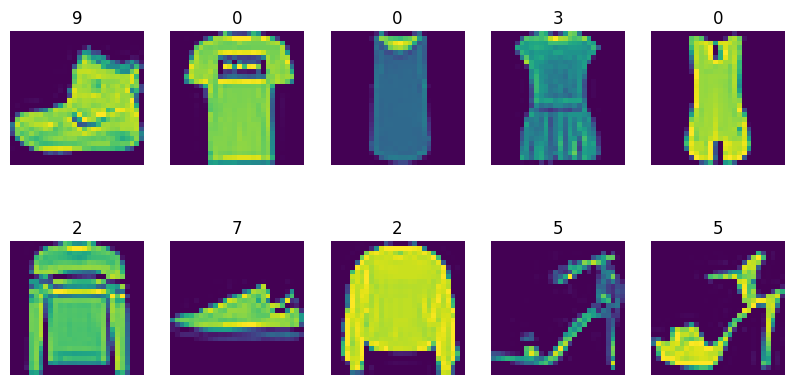

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.title(y_train[i])
  plt.imshow(x_train[i])
  plt.axis('off')
plt.show()

In [ ]:
x_train = x_train.astype('float32')
x_train = (x_train - 127.5) / 127.5


In [ ]:
x_train = np.expand_dims(x_train, axis=-1)

In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


In [ ]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(tf.keras.layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # Note: None is the batch size

    model.add(tf.keras.layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(tf.keras.layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(tf.keras.layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


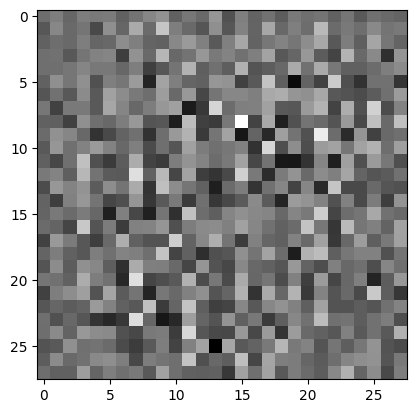

In [ ]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [ ]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 1]))
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(1))

    return model

In [ ]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.Tensor([[0.00169042]], shape=(1, 1), dtype=float32)


In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [ ]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [ ]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16
BATCH_SIZE = 256
seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [ ]:

def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return {
        'gen_loss': gen_loss.numpy() if hasattr(gen_loss, 'numpy') else float(gen_loss),
        'disc_loss': disc_loss.numpy() if hasattr(disc_loss, 'numpy') else float(disc_loss)
    }

In [ ]:
def train(epochs, dataset):
    D_loss=[] # список для сбора значений потерь для дискриминатора
    G_loss=[] # список для сбора значений потерь для генератора
    for epoch in range(epochs):
        start = time.time()
        print("\nЭпоха : {}".format(epoch + 1))
        for images in dataset:
            loss = train_step(images)
        print(" Время:{}".format(np.round(time.time() - start),2))
        print("Generator Loss: {} Discriminator Loss: {}".format(loss['gen_loss'],loss['disc_loss']))
        D_loss.append(loss['disc_loss'])
        G_loss.append(loss['gen_loss'])
    return (G_loss, D_loss)

In [ ]:
G, D = train(50, train_dataset)


Эпоха : 1
 Время:53.0
Generator Loss: 0.9817113876342773 Discriminator Loss: 1.165331244468689

Эпоха : 2
 Время:53.0
Generator Loss: 1.1789555549621582 Discriminator Loss: 0.8977195620536804

Эпоха : 3
 Время:52.0
Generator Loss: 0.8251863718032837 Discriminator Loss: 1.330230951309204

Эпоха : 4
 Время:52.0
Generator Loss: 1.0493121147155762 Discriminator Loss: 1.2666206359863281

Эпоха : 5
 Время:52.0
Generator Loss: 1.14420747756958 Discriminator Loss: 1.0909355878829956

Эпоха : 6
 Время:82.0
Generator Loss: 1.1723631620407104 Discriminator Loss: 0.9008524417877197

Эпоха : 7
 Время:52.0
Generator Loss: 1.3908742666244507 Discriminator Loss: 0.8388724327087402

Эпоха : 8
 Время:52.0
Generator Loss: 1.4828029870986938 Discriminator Loss: 0.7847573757171631

Эпоха : 9
 Время:51.0
Generator Loss: 1.4803080558776855 Discriminator Loss: 0.9822721481323242

Эпоха : 10
 Время:51.0
Generator Loss: 2.2303073406219482 Discriminator Loss: 0.6542134284973145

Эпоха : 11
 Время:51.0
Generator

Генерация изображений
Изображения сохранены как 'generated_images_epoch_1.png'


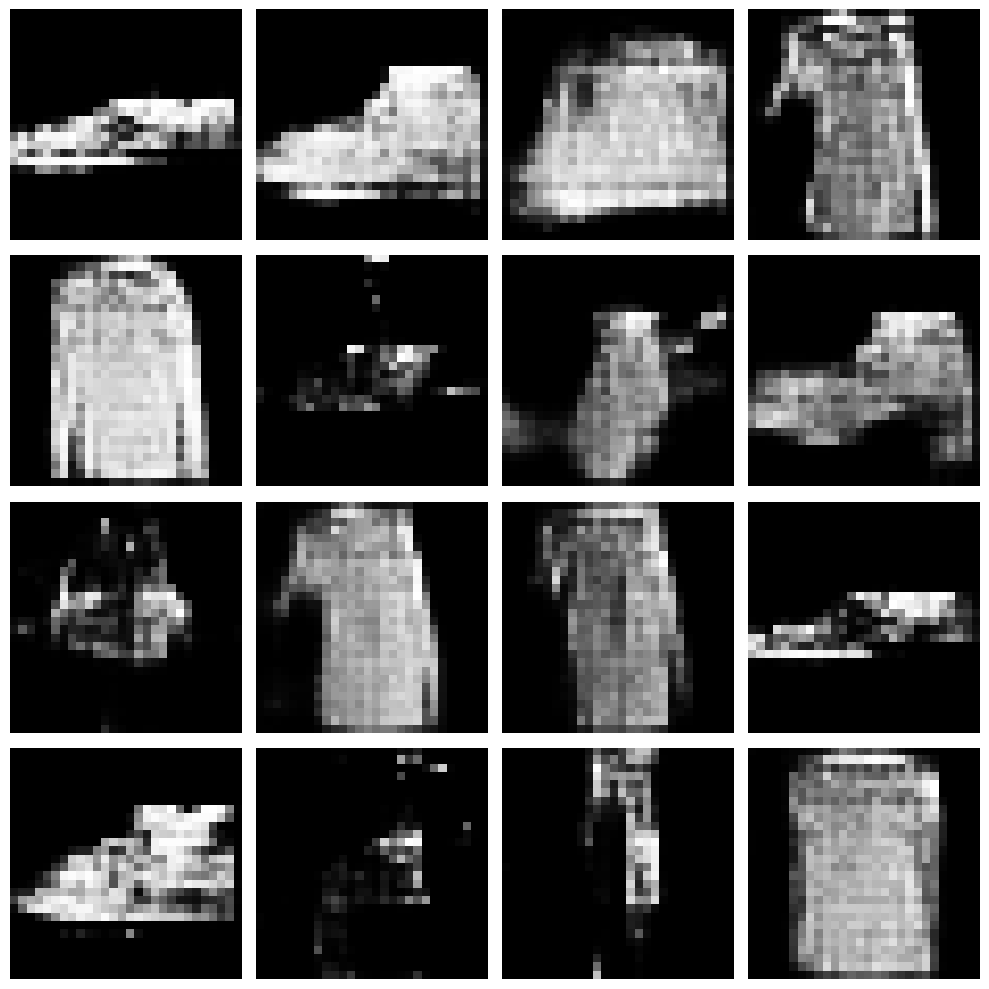

In [ ]:
def generate_and_plot_images(generator, noise_dim, num_examples=16, save=False, epoch=0):
    noise = tf.random.normal([num_examples, noise_dim])

    generated_images = generator(noise, training=False)


    generated_images = (generated_images + 1) / 2.0


    plt.figure(figsize=(10, 10))


    grid_size = int(np.sqrt(num_examples))

    for i in range(num_examples):
        plt.subplot(grid_size, grid_size, i + 1)

        if generated_images.shape[-1] == 1:
            plt.imshow(generated_images[i, :, :, 0], cmap='gray')
        else:
            plt.imshow(generated_images[i, :, :, :])

        plt.axis('off')

    plt.tight_layout()

    if save:
        plt.savefig(f'generated_images_epoch_{epoch+1}.png')
        print(f"Изображения сохранены как 'generated_images_epoch_{epoch+1}.png'")

    plt.show()


print("Генерация изображений")
generate_and_plot_images(generator, noise_dim, num_examples=16, save=True)